# Predicting Shelter Animal Adoption Outcomes
## Austin Animal Center — Dogs and Cats | 2013–2025

This notebook presents the full data analytics pipeline for a WGU B.S. Data Analytics 
Capstone project by Heather Stukenbroer. The project uses historical intake and outcome 
data from the Austin Animal Center to build a random forest classification model that 
predicts whether a dog or cat will be adopted, returned to its owner, transferred, 
or face euthanasia based on characteristics present at the time of intake.

**Research Question:** Which animal characteristics — including species, age, breed, 
color, sex, neuter status, intake type, intake condition, and length of stay — most 
strongly predict adoption outcomes for dogs and cats at the Austin Animal Center?

**Dataset:** Austin Animal Center Intakes and Outcomes — City of Austin Open Data Portal  
**Records:** 178,122 after cleaning and preparation  
**Model:** Random Forest Classifier — 76% overall accuracy  
**Tools:** Python, pandas, scikit-learn, matplotlib, seaborn, VS Code, Jupyter Notebook

### Step 1 - Data Loading ###
*   In this step, the Austin Animal Center Intakes and Outcomes CSV files are loaded 
into Python as separate pandas DataFrames. The necessary libraries are imported 
and initial verification checks are performed to confirm the data loaded correctly.

In [35]:
import pandas as pd

#define base path
base_path = r"C:\Users\hstuken\OneDrive - Western Governors University\Capstone project\Capstone Data"

#Load Intake Files
intakes = pd.read_csv(base_path + r"\Austin_Animal_Center_Intakes_(10_01_2013_to_05_05_2025)_20260325.csv")

#Load Outcome Files
outcomes = pd.read_csv(base_path + r"\Austin_Animal_Center_Outcomes_(10_01_2013_to_05_05_2025)_20260325.csv")


In [36]:
#Verify the dataframes
print(intakes.head())
print(outcomes.head())  

  Animal ID    Name                DateTime     MonthYear  \
0   A521520    Nina  10/01/2013 07:51:00 AM  October 2013   
1   A664235     NaN  10/01/2013 08:33:00 AM  October 2013   
2   A664236     NaN  10/01/2013 08:33:00 AM  October 2013   
3   A664237     NaN  10/01/2013 08:33:00 AM  October 2013   
4   A664233  Stevie  10/01/2013 08:53:00 AM  October 2013   

                   Found Location Intake Type Intake Condition Animal Type  \
0         Norht Ec in Austin (TX)       Stray           Normal         Dog   
1             Abia in Austin (TX)       Stray           Normal         Cat   
2             Abia in Austin (TX)       Stray           Normal         Cat   
3             Abia in Austin (TX)       Stray           Normal         Cat   
4  7405 Springtime in Austin (TX)       Stray          Injured         Dog   

  Sex upon Intake Age upon Intake                         Breed         Color  
0   Spayed Female         7 years  Border Terrier/Border Collie     White/Tan  
1   

In [37]:
#Checking the column names of the two four datasset to ensure they are the same before merging
print(f"Intake Column Names: {intakes.columns.tolist()}")
print(f"Outcomes Column Names: {outcomes.columns.tolist()}")

Intake Column Names: ['Animal ID', 'Name', 'DateTime', 'MonthYear', 'Found Location', 'Intake Type', 'Intake Condition', 'Animal Type', 'Sex upon Intake', 'Age upon Intake', 'Breed', 'Color']
Outcomes Column Names: ['Animal ID', 'Date of Birth', 'Name', 'DateTime', 'MonthYear', 'Outcome Type', 'Outcome Subtype', 'Animal Type', 'Sex upon Outcome', 'Age upon Outcome', 'Breed', 'Color']


### Step 2 - Data Filtering ###
*   In this step, both datasets are filtered to include only dogs and cats using the 
Animal Type column. The filtered intake and outcome DataFrames are then joined on 
the shared Animal ID field using an inner join, retaining only records that contain 
both an intake and a corresponding outcome.

In [85]:
#filter to dogs and cats only
intakes_dc = intakes[intakes['Animal Type'].isin(['Dog', 'Cat'])]
outcomes_dc = outcomes[outcomes['Animal Type'].isin(['Dog', 'Cat'])]        

print(f"Intakes: {intakes_dc.shape[0]}")
print(f"Outcomes: {outcomes_dc.shape[0]}")
print(f"Intakes by type:", intakes_dc['Animal Type'].value_counts().to_dict())
print(f"Outcomes by type:", outcomes_dc['Animal Type'].value_counts().to_dict())


Intakes: 163932
Outcomes: 163904
Intakes by type: {'Dog': 94608, 'Cat': 69324}
Outcomes by type: {'Dog': 94505, 'Cat': 69399}


In [86]:
#join intakes and outcomes on animal_id
df = pd.merge(intakes_dc, outcomes_dc, on='Animal ID',how='inner')

print(f"Joined DataFrame shape: {df.shape}")
print(df.head())   
print(df.columns.tolist())

Joined DataFrame shape: (211295, 23)
  Animal ID  Name_x              DateTime_x   MonthYear_x  \
0   A521520    Nina  10/01/2013 07:51:00 AM  October 2013   
1   A664235     NaN  10/01/2013 08:33:00 AM  October 2013   
2   A664236     NaN  10/01/2013 08:33:00 AM  October 2013   
3   A664237     NaN  10/01/2013 08:33:00 AM  October 2013   
4   A664233  Stevie  10/01/2013 08:53:00 AM  October 2013   

                   Found Location Intake Type Intake Condition Animal Type_x  \
0         Norht Ec in Austin (TX)       Stray           Normal           Dog   
1             Abia in Austin (TX)       Stray           Normal           Cat   
2             Abia in Austin (TX)       Stray           Normal           Cat   
3             Abia in Austin (TX)       Stray           Normal           Cat   
4  7405 Springtime in Austin (TX)       Stray          Injured           Dog   

  Sex upon Intake Age upon Intake  ...  Name_y           DateTime_y  \
0   Spayed Female         7 years  ...    Ni

### Step 3 - Data Cleaning ###
*   In this step, duplicate and unnecessary columns are removed, missing values are 
identified and addressed, and data types are converted to their appropriate formats. 
These cleaning steps ensure the dataset is accurate and consistent before 
feature engineering and modeling.

In [87]:
#drop duplicate columns and rename columns to avoid confusion
df = df.drop(columns=['Name_y', 'MonthYear_y', 'Animal Type_y', 'Breed_y', 'Color_y']) 
df = df.rename(columns={
    'Name_x': 'Name',
    'DateTime_x': 'Intake DateTime',
    'MonthYear_x': 'Intake MonthYear',
    'Animal Type_x': 'Animal Type',
    'Breed_x': 'Breed',
    'Color_x': 'Color',
    'DateTime_y': 'Outcome DateTime',
})

print("Cleaned columns:", df.columns.tolist())
print("Shape:", df.shape)

Cleaned columns: ['Animal ID', 'Name', 'Intake DateTime', 'Intake MonthYear', 'Found Location', 'Intake Type', 'Intake Condition', 'Animal Type', 'Sex upon Intake', 'Age upon Intake', 'Breed', 'Color', 'Date of Birth', 'Outcome DateTime', 'Outcome Type', 'Outcome Subtype', 'Sex upon Outcome', 'Age upon Outcome']
Shape: (211295, 18)


In [88]:
#Checking data types 
print(df.dtypes)

Animal ID           str
Name                str
Intake DateTime     str
Intake MonthYear    str
Found Location      str
Intake Type         str
Intake Condition    str
Animal Type         str
Sex upon Intake     str
Age upon Intake     str
Breed               str
Color               str
Date of Birth       str
Outcome DateTime    str
Outcome Type        str
Outcome Subtype     str
Sex upon Outcome    str
Age upon Outcome    str
dtype: object


In [89]:
#convert data columns to datetime
df['Intake DateTime'] = pd.to_datetime(df['Intake DateTime'])
df["Intake MonthYear"] = pd.to_datetime(df["Intake MonthYear"], format="%B %Y")

#convert outcome datetime to datetime using ISO8601 format
df['Outcome DateTime'] = pd.to_datetime(df['Outcome DateTime'], format='ISO8601', utc=True)

#remove timezone information to match intake datetime
df['Outcome DateTime'] = df['Outcome DateTime'].dt.tz_localize(None)


In [90]:
#Verify the conversions
print(df.dtypes)
print(df["Intake MonthYear"].head())
print(df["Intake DateTime"].head())

Animal ID                      str
Name                           str
Intake DateTime     datetime64[us]
Intake MonthYear    datetime64[us]
Found Location                 str
Intake Type                    str
Intake Condition               str
Animal Type                    str
Sex upon Intake                str
Age upon Intake                str
Breed                          str
Color                          str
Date of Birth                  str
Outcome DateTime    datetime64[us]
Outcome Type                   str
Outcome Subtype                str
Sex upon Outcome               str
Age upon Outcome               str
dtype: object
0   2013-10-01
1   2013-10-01
2   2013-10-01
3   2013-10-01
4   2013-10-01
Name: Intake MonthYear, dtype: datetime64[us]
0   2013-10-01 07:51:00
1   2013-10-01 08:33:00
2   2013-10-01 08:33:00
3   2013-10-01 08:33:00
4   2013-10-01 08:53:00
Name: Intake DateTime, dtype: datetime64[us]


In [91]:
#convert Age upon Intake from str to days
def age_to_days(age_str):
    try:
        parts = str(age_str).lower().split()
        value = int(parts[0])
        unit = parts[1]
        if 'day' in unit:
            return value
        elif 'week' in unit:
            return value * 7
        elif 'month' in unit:
            return value * 30
        elif 'year' in unit:
            return value * 365
        else:
            return 0
    except:
        return 0
df['Age upon Intake'] = df['Age upon Intake'].apply(age_to_days)

print("Age upon Intake converted to days")
print(df['Age upon Intake'].describe())

Age upon Intake converted to days
count    211295.000000
mean        786.095610
std        1039.697224
min       -1460.000000
25%          60.000000
50%         365.000000
75%        1095.000000
max        8760.000000
Name: Age upon Intake, dtype: float64


In [92]:
#drop rows with negative age upon intake
df = df[df['Age upon Intake'] >= 0]

print("Shape after removing negative ages:", df.shape)
print("Age upon Intake after cleaning:", df['Age upon Intake'].describe())

Shape after removing negative ages: (211275, 18)
Age upon Intake after cleaning: count    211275.000000
mean        786.227036
std        1039.653051
min           0.000000
25%          60.000000
50%         365.000000
75%        1095.000000
max        8760.000000
Name: Age upon Intake, dtype: float64


In [93]:
#check for missing values
print(df.isnull().sum())

Animal ID                0
Name                 42635
Intake DateTime          0
Intake MonthYear         0
Found Location           0
Intake Type              0
Intake Condition         0
Animal Type              0
Sex upon Intake          1
Age upon Intake          0
Breed                    0
Color                    0
Date of Birth            0
Outcome DateTime         0
Outcome Type            61
Outcome Subtype     131640
Sex upon Outcome         1
Age upon Outcome         5
dtype: int64


In [94]:
#drop columnn "Outcome Subtype" and "Name" due to high number of missing values
df = df.drop(columns=['Outcome Subtype'])
df = df.drop(columns=['Name'])

In [95]:
#check for missing values after dropping column
print(df.isnull().sum())

Animal ID            0
Intake DateTime      0
Intake MonthYear     0
Found Location       0
Intake Type          0
Intake Condition     0
Animal Type          0
Sex upon Intake      1
Age upon Intake      0
Breed                0
Color                0
Date of Birth        0
Outcome DateTime     0
Outcome Type        61
Sex upon Outcome     1
Age upon Outcome     5
dtype: int64


In [96]:
#Drop rows with missing values in "Outcome Type" since it is critical for analysis
df = df.dropna(subset=['Outcome Type'])    
#check for missing values after dropping rows
print(df.isnull().sum())

Animal ID           0
Intake DateTime     0
Intake MonthYear    0
Found Location      0
Intake Type         0
Intake Condition    0
Animal Type         0
Sex upon Intake     1
Age upon Intake     0
Breed               0
Color               0
Date of Birth       0
Outcome DateTime    0
Outcome Type        0
Sex upon Outcome    1
Age upon Outcome    5
dtype: int64


In [97]:
#drop remining rows with missing values
df = df.dropna(subset=['Sex upon Intake', 'Sex upon Outcome', 'Age upon Outcome'])
#check for missing values after dropping rows
print(df.isnull().sum())

Animal ID           0
Intake DateTime     0
Intake MonthYear    0
Found Location      0
Intake Type         0
Intake Condition    0
Animal Type         0
Sex upon Intake     0
Age upon Intake     0
Breed               0
Color               0
Date of Birth       0
Outcome DateTime    0
Outcome Type        0
Sex upon Outcome    0
Age upon Outcome    0
dtype: int64


### Step 4 - Feature Engineering ###
*    In this step, the Length of Stay feature is calculated for each animal by subtracting 
the Intake DateTime from the Outcome DateTime. The Intake Month feature is also 
extracted from the Intake DateTime column to capture seasonal patterns. Outcome 
categories are consolidated from eleven original values into four meaningful groups, 
and all categorical predictor variables are encoded as numeric values in preparation 
for modeling.

In [51]:
#calculate length of stay in days
df['Intake DateTime'] = pd.to_datetime(df['Intake DateTime'])
df['Outcome DateTime'] = pd.to_datetime(df['Outcome DateTime'])

df['Length of Stay'] = (df['Outcome DateTime'] - df['Intake DateTime']).dt.days


#Print
print("Length of Stay Stats:")
print(df['Length of Stay'].describe())
print("\nNegative Length of Stay Count:", (df['Length of Stay'] < 0).sum())




Length of Stay Stats:
count    211208.000000
mean         20.928185
std         309.343903
min       -3881.000000
25%           1.000000
50%           6.000000
75%          30.000000
max        3883.000000
Name: Length of Stay, dtype: float64

Negative Length of Stay Count: 24777


* We will need to remove records with invalid length of stay values. Negative values in the above calculation indicates mismatched intake and outcome records due to animals with multiple intakes. Values over 365 days are going to be treated as outliers in this analysis.

In [52]:
#drop rows with negative length of stay since they are likely data errors
df = df[df['Length of Stay'] >= 0]

#also drop rows with length of stay greater than 365 days since they are likely outliers
df = df[df['Length of Stay'] <= 365]

#verify the length of stay after cleaning
print("Length of Stay Stats After Cleaning:", df.shape)
print("\nLength of Stay Stats After Cleaning:")
print(df['Length of Stay'].describe())  

Length of Stay Stats After Cleaning: (178122, 17)

Length of Stay Stats After Cleaning:
count    178122.000000
mean         28.934595
std          54.250534
min           0.000000
25%           3.000000
50%           7.000000
75%          30.000000
max         365.000000
Name: Length of Stay, dtype: float64


In [53]:
#extract intake month from intake datetime
df['Intake Month'] = df['Intake DateTime'].dt.month


print("Intake Month extracted from Intake DateTime")
print(df['Intake Month'].value_counts().sort_index())

Intake Month extracted from Intake DateTime
Intake Month
1     13190
2     11919
3     13309
4     14387
5     18190
6     17188
7     15790
8     15315
9     15374
10    16414
11    13970
12    13076
Name: count, dtype: int64


### Step 5 - Exploratory Analysis ###
*   In this step, the cleaned dataset is explored through summary statistics and 
visualizations to identify patterns and relationships between animal characteristics 
and adoption outcomes. These visualizations inform feature selection decisions and 
establish the analytical context for the classification model developed in Step 6.

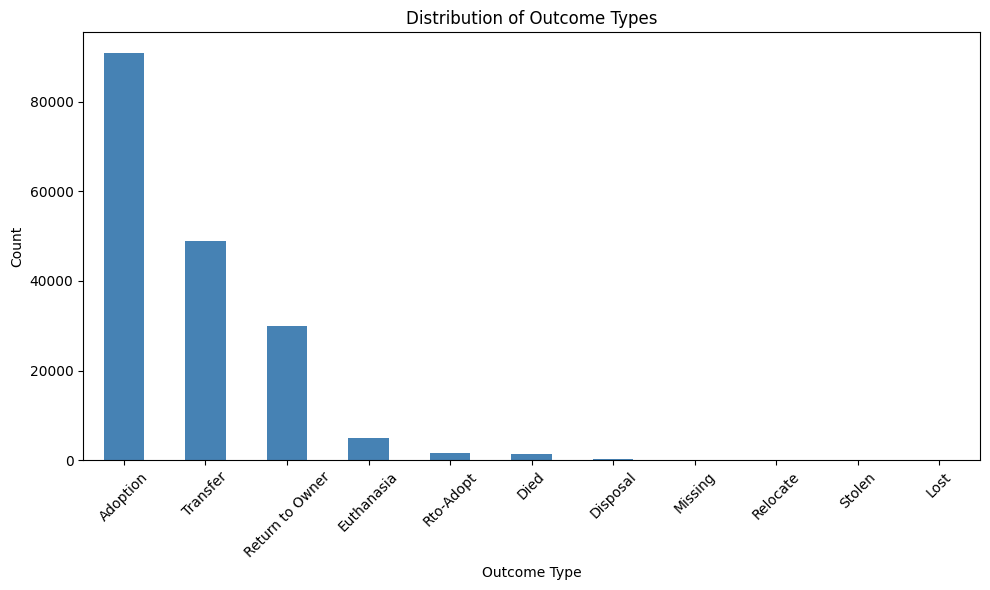

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

#outcome type distribution figure
plt.figure(figsize=(10, 6))
df['Outcome Type'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Distribution of Outcome Types')
plt.xlabel('Outcome Type')  
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Outcome Category Distribution:
Outcome Category
Adopted              92420
Transferred          48989
Returned to Owner    29978
Other                 6735
Name: count, dtype: int64


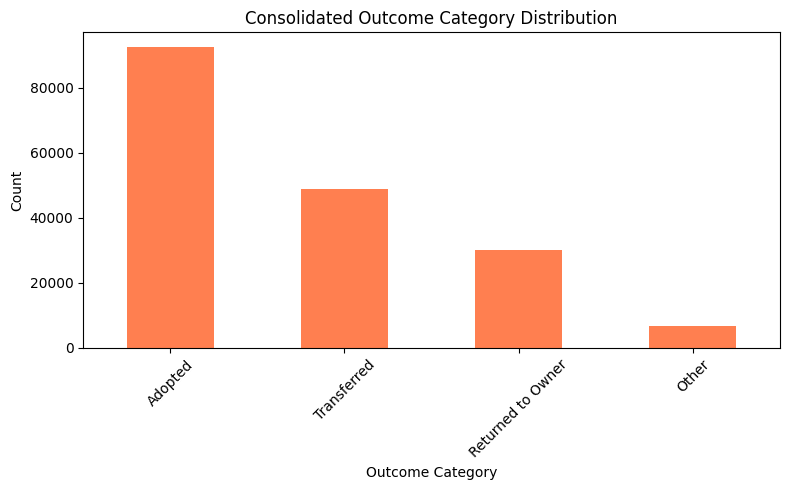

In [78]:
#consolidate outcome types into four main outcome categories 
outcome_mapping = {
    'Adoption' : 'Adopted',
    'Rto-Adopt' : 'Adopted', 
    'Transfer' : 'Transferred', 
    'Relocate' : 'Transferred',
    'Return to Owner' : 'Returned to Owner',
    'Euthanasia' : 'Other',
    'Died' : 'Other', 
    'Disposal' : 'Other',
    'Missing' : 'Other', 
    'Stolen' : 'Other',
    'Lost' : 'Other', 
}

df['Outcome Category'] = df['Outcome Type'].map(outcome_mapping)

print("Outcome Category Distribution:")
print(df['Outcome Category'].value_counts())

#plot the new outcome category distribution
plt.figure(figsize=(8, 5))
df['Outcome Category'].value_counts().plot(kind='bar', color='coral')
plt.title('Consolidated Outcome Category Distribution')
plt.xlabel('Outcome Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

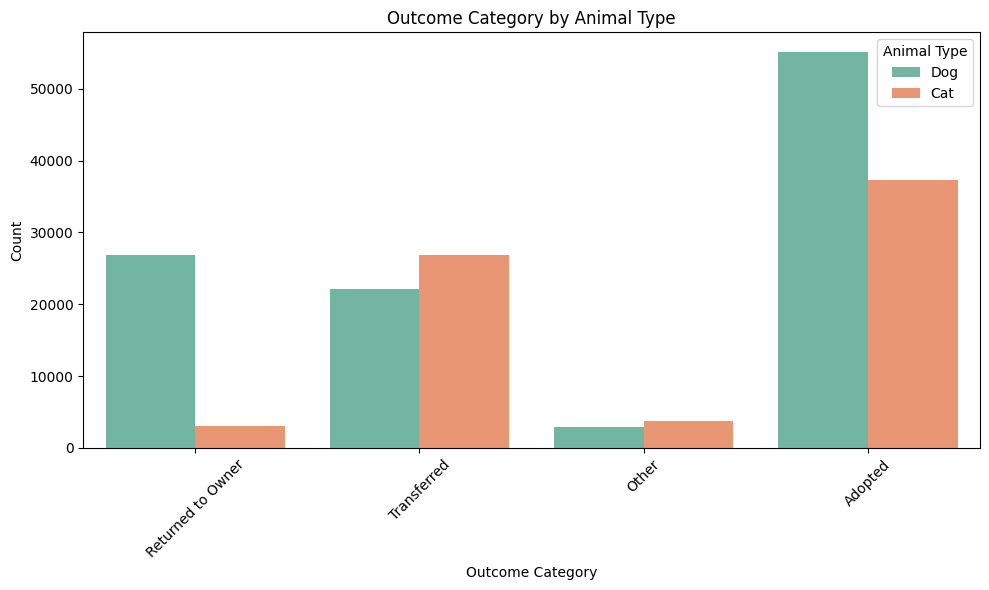

In [79]:
#outcome by animal type visual
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Outcome Category', hue='Animal Type', palette='Set2')
plt.title('Outcome Category by Animal Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Animal Type')
plt.tight_layout()
plt.show()


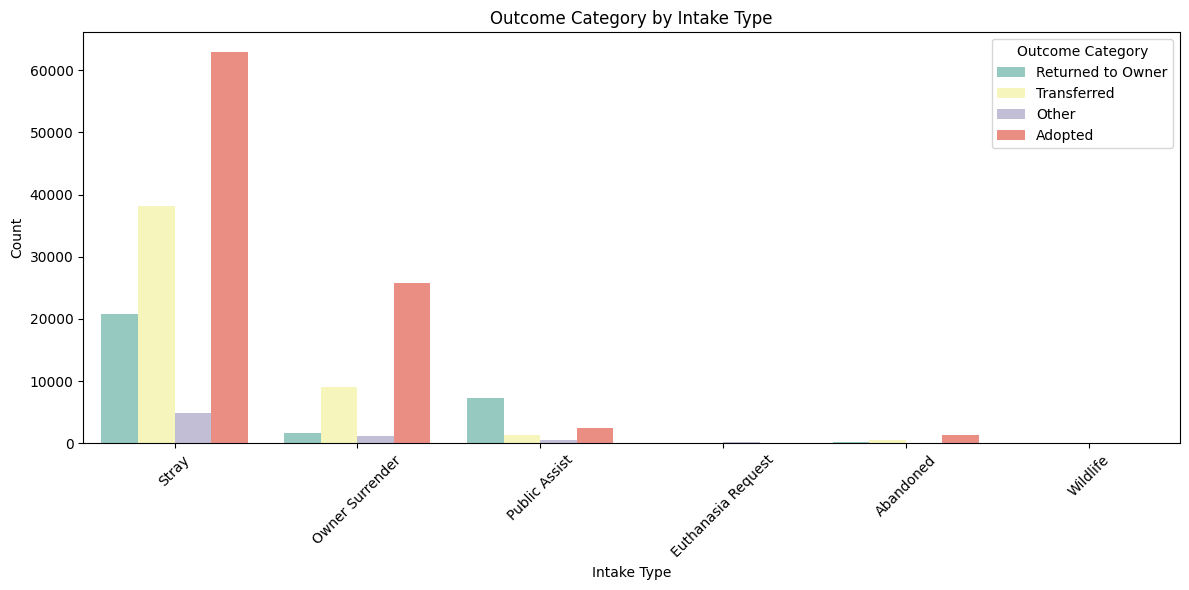

In [80]:
#outcome by intake type visual
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Intake Type', hue='Outcome Category', palette='Set3')
plt.title('Outcome Category by Intake Type')
plt.xlabel('Intake Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Outcome Category')
plt.tight_layout()
plt.show()

C:\Users\hstuken\AppData\Local\Temp\ipykernel_23412\3440284060.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Outcome Category', y='Length of Stay', palette='Set2')


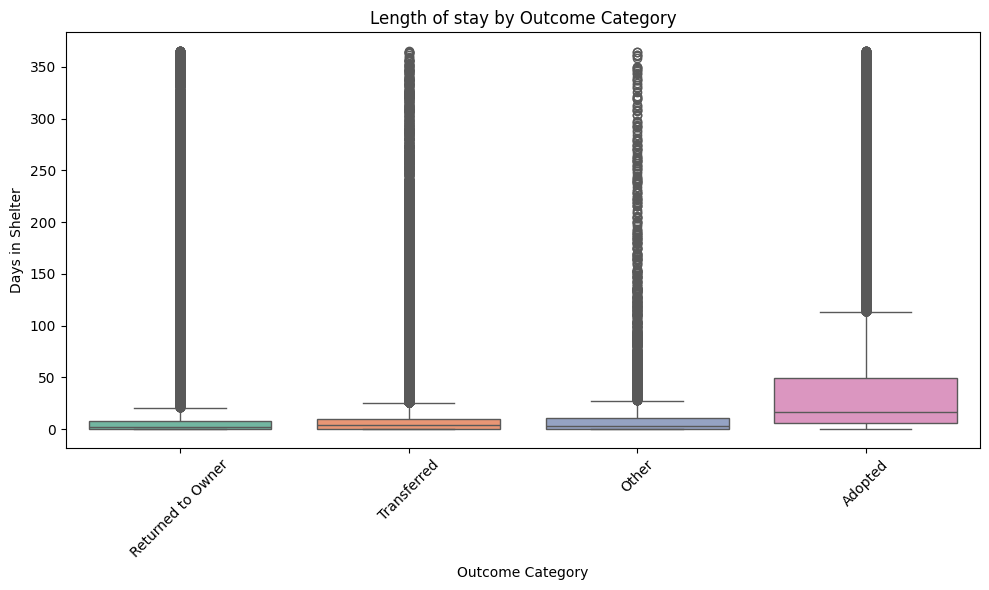

In [81]:
#length of stay by outcome category

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Outcome Category', y='Length of Stay', palette='Set2')
plt.title('Length of stay by Outcome Category')
plt.xlabel('Outcome Category')
plt.ylabel('Days in Shelter')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

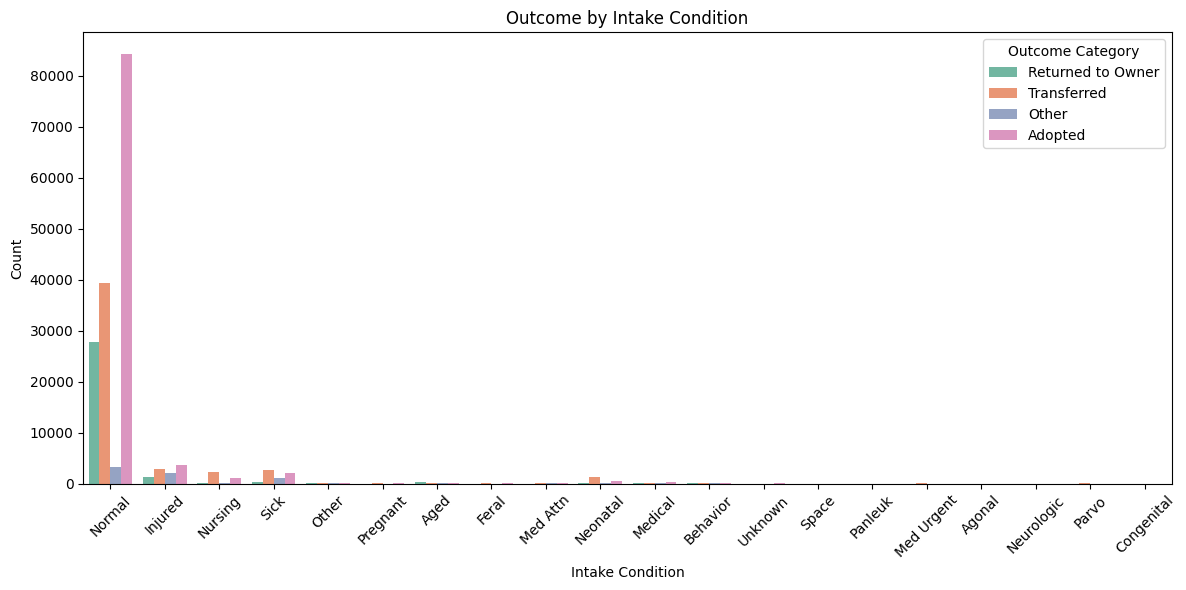

In [82]:
#outcome by intake condition visual
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='Intake Condition', hue='Outcome Category', palette='Set2')
plt.title('Outcome by Intake Condition')
plt.xlabel('Intake Condition')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Outcome Category')
plt.tight_layout()
plt.show()

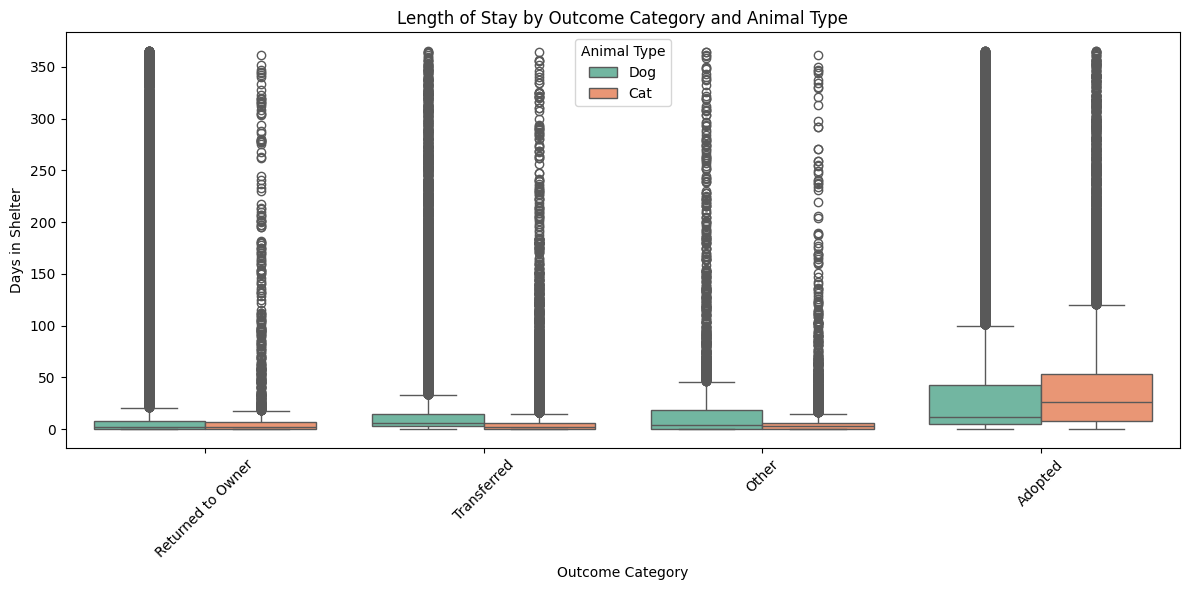

Outcome Category   Animal Type
Adopted            Cat            39.1
                   Dog            39.1
Other              Cat            10.5
                   Dog            24.9
Returned to Owner  Cat            12.8
                   Dog            25.5
Transferred        Cat             8.1
                   Dog            21.7
Name: Length of Stay, dtype: float64


In [83]:
#average lengthe of stay by age upon intake
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Outcome Category', y='Length of Stay', hue='Animal Type', palette='Set2')
plt.title('Length of Stay by Outcome Category and Animal Type')
plt.xlabel('Outcome Category')
plt.ylabel('Days in Shelter')
plt.xticks(rotation=45)
plt.legend(title='Animal Type')
plt.tight_layout()
plt.show()

#also print average length of stay by outcome and animal type
print(df.groupby(['Outcome Category', 'Animal Type'])['Length of Stay'].mean().round(1))

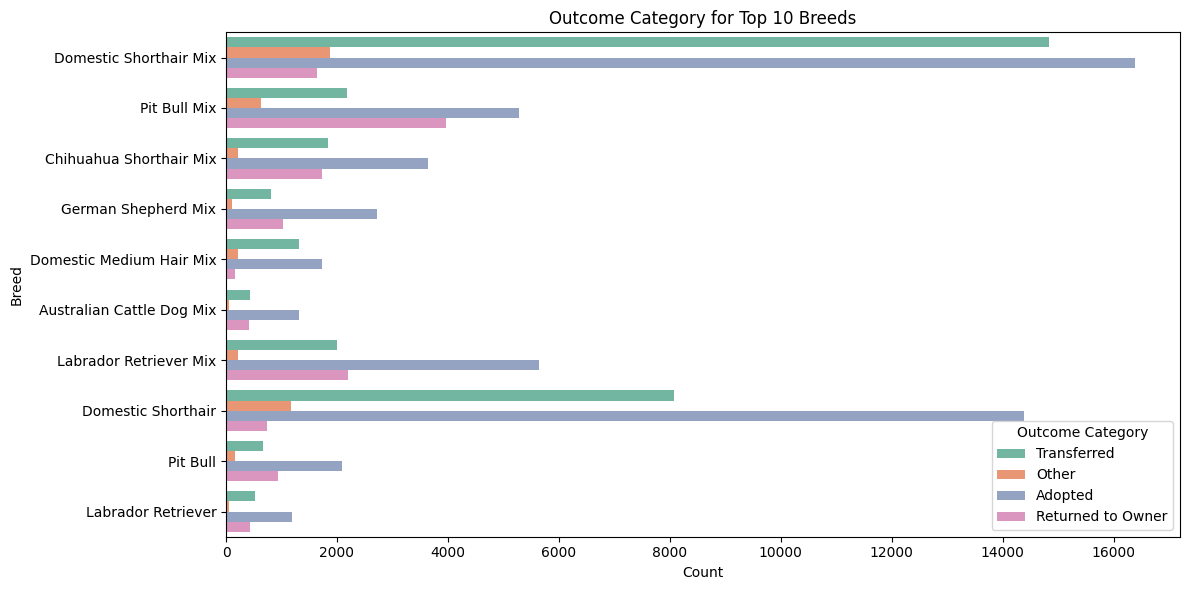

In [84]:
#top 10 breeds by count
top_breeds = df['Breed'].value_counts().head(10).index

plt.figure(figsize=(12, 6))
breed_df = df[df['Breed'].isin(top_breeds)]
sns.countplot(data=breed_df, y='Breed', hue='Outcome Category', palette='Set2')
plt.title('Outcome Category for Top 10 Breeds')
plt.xlabel('Count')
plt.ylabel('Breed')
plt.legend(title='Outcome Category')
plt.tight_layout()
plt.show()

### Step 6 - Model Building ###
*   In this step, the prepared dataset is split into 80% training and 20% testing sets 
using stratified sampling to ensure balanced class representation across all four 
outcome categories. A random forest classification model is trained on the training 
set using 100 decision trees. Model performance is then evaluated on the test set 
using a classification report, confusion matrix, and feature importance analysis.

In [62]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import numpy as np

#select features for the model
features = ['Animal Type',
            'Intake Type',
            'Intake Condition', 
            'Sex upon Intake',
            'Breed',
            'Color',
            'Length of Stay',
            'Age upon Intake',
            'Intake Month'
            ]

#define X and y
X = df[features].copy()
y = df['Outcome Category']

print("Feature shape:", X.shape)
print("Target distribution:")
print(y.value_counts() )

Feature shape: (178122, 9)
Target distribution:
Outcome Category
Adopted              92420
Transferred          48989
Returned to Owner    29978
Other                 6735
Name: count, dtype: int64


In [63]:
#encode categorical variables
cat_columns = ['Animal Type', 'Intake Type', 'Intake Condition', 'Sex upon Intake', 'Breed', 'Color']

le = LabelEncoder()
for col in cat_columns:
    X[col] = le.fit_transform(X[col].astype(str))
    
print("Encoding Complete!")
print(X.dtypes)
print(X.head())

Encoding Complete!
Animal Type         int64
Intake Type         int64
Intake Condition    int64
Sex upon Intake     int64
Breed               int64
Color               int64
Length of Stay      int64
Age upon Intake     int64
Intake Month        int32
dtype: object
   Animal Type  Intake Type  Intake Condition  Sex upon Intake  Breed  Color  \
0            1            4                11                3    578    599   
1            0            4                11                4   1260    392   
2            0            4                11                4   1260    392   
3            0            4                11                4   1260    392   
4            1            4                 5                0   2084    136   

   Length of Stay  Age upon Intake  Intake Month  
0               0             2555            10  
1               0                7            10  
2               0                7            10  
3               0                7            10

In [64]:
#split data into training and testing sets
X_train,X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training setsize:", X_train.shape)
print("Test set size:", X_test.shape)
print("Training target distribution:")
print(y_train.value_counts().sort_index())  
print("Test target distribution:")
print(y_test.value_counts().sort_index())

Training setsize: (142497, 9)
Test set size: (35625, 9)
Training target distribution:
Outcome Category
Adopted              73936
Other                 5388
Returned to Owner    23982
Transferred          39191
Name: count, dtype: int64
Test target distribution:
Outcome Category
Adopted              18484
Other                 1347
Returned to Owner     5996
Transferred           9798
Name: count, dtype: int64


In [65]:
#train random forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Model TrainingComplete!")
print("Number of Trees:", rf_model.n_estimators)

Model TrainingComplete!
Number of Trees: 100


In [66]:
#evaluate model performance
y_pred =rf_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
                   precision    recall  f1-score   support

          Adopted       0.77      0.92      0.83     18484
            Other       0.56      0.28      0.37      1347
Returned to Owner       0.82      0.73      0.77      5996
      Transferred       0.73      0.56      0.63      9798

         accuracy                           0.76     35625
        macro avg       0.72      0.62      0.65     35625
     weighted avg       0.76      0.76      0.75     35625



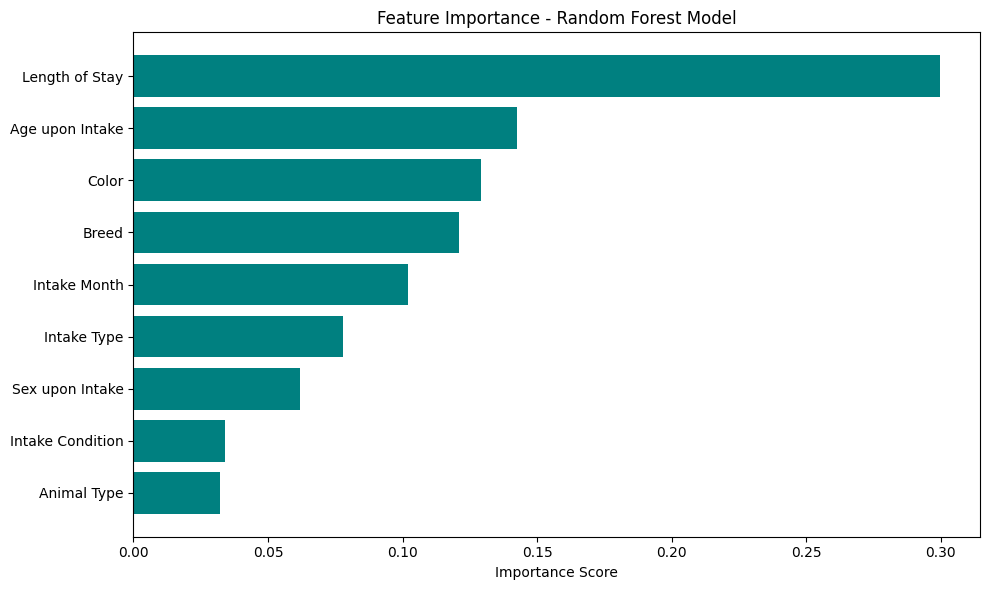

Feature Importance Scores:
            Feature  Importance
6    Length of Stay    0.299568
7   Age upon Intake    0.142400
5             Color    0.129200
4             Breed    0.120920
8      Intake Month    0.101989
1       Intake Type    0.078031
3   Sex upon Intake    0.061962
2  Intake Condition    0.033845
0       Animal Type    0.032086


In [67]:
#Feature importance
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='teal')
plt.title('Feature Importance - Random Forest Model')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("Feature Importance Scores:")
print(feature_importance.sort_values(by='Importance', ascending=False))

### Confusion Matrix
*   The confusion matrix below visualizes the model's predictions against the actual 
outcomes for the test dataset. Each row represents the actual outcome category and 
each column represents the predicted outcome category. The diagonal values represent 
correct predictions, while off-diagonal values represent misclassifications. This 
allows us to identify which outcome categories the model predicts most accurately 
and where it tends to make errors.

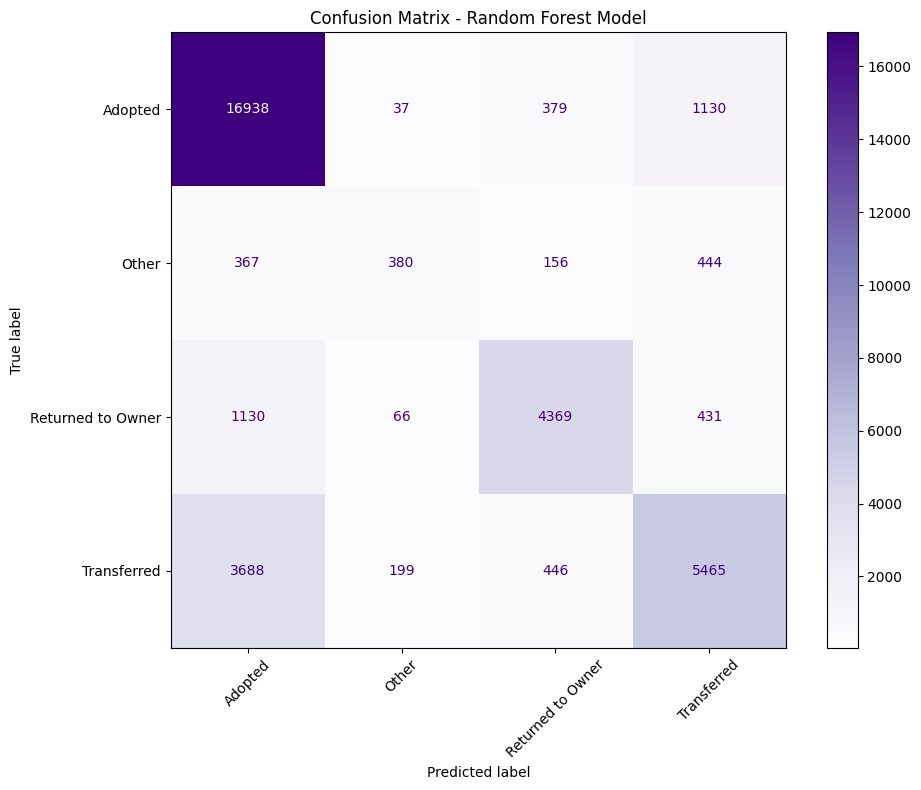

In [68]:
# Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)

plt.figure(figsize=(10, 8))
disp.plot(cmap='Purples', ax=plt.gca())
plt.title('Confusion Matrix - Random Forest Model')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

* The model performs strongest on the Adopted category with a recall of 0.92, correctly 
identifying 92% of all animals that were actually adopted. The Other category shows 
the weakest performance due to class imbalance, as it contains significantly fewer 
records than the other three categories.